# Churn Risk & Budget-Constrained Retention Targeting
### Data Scientist Take-Home Assignment — Notebook Deliverable

**Author:** Ankush
**Data:** Synthetic (generated in this notebook, `customers.csv`, 20,000 rows)
**Tiers completed:** Tier 1 (Foundations) · Tier 2 (Modeling & Targeting) · Tier 3 (Simulation & Experimentation)

---

**How to read this notebook:** it is organized exactly around the tiers in the brief. Each tier section
starts with a short markdown framing, followed by runnable code, followed by the required outputs
(metrics, tables, charts). All business assumptions live in a single `ASSUMPTIONS` config cell so they
are transparent and easy to adjust, per the Tier 3 requirement.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Environment ready.")


Environment ready.


## Tier 1 — Foundations

### T1.1 — Problem Framing

- **Business objective:** protect *net retained revenue* over the next 30 days for a subscription
  business, not just minimize churn count — a retention offer that saves a low-value customer can
  still destroy value once its cost is netted out.
- **Prediction objective:** for every *active customer* as of today, predict the probability that
  they **churn within the next 30 days** (`churn_next_30d`), using account, usage, engagement and
  market-context features available at scoring time (no post-outcome information).
- **Decision objective:** rank customers by churn risk and, subject to a **hard budget constraint
  (≤30% of active customers can be targeted)**, decide who receives a retention offer that costs
  **20% of that customer's monthly fee** — choosing the threshold that maximizes expected net
  retained revenue rather than simply targeting the highest-risk customers.
- **Why this is a constrained optimization, not just a classification problem:** with a 30% budget
  cap, the model's job is less "who will churn" and more "who is the highest-value *save*" —
  i.e., high risk **and** high monthly fee **and** plausibly persuadable by an offer.
- **Success metric for the exercise:** AUC / lift tell us the model discriminates risk well; the
  metric that actually matters to leadership is **estimated net retained revenue** under the
  budget constraint, computed in Tier 2.2.


### Data — Synthetic Generation

We generate `customers.csv` with 20,000 active customers and the suggested columns. Relationships
are deliberately encoded so that low engagement, high support tickets, an outstanding invoice, and
more competing offers in the region raise churn risk, while longer tenure and premium plans lower it
— mirroring the guidance in the brief. A small amount of realistic missingness and a few outliers are
injected on purpose so the EDA / data-quality section below has real issues to find (not a synthetic
data giveaway).


In [2]:
N = 20_000
rng = np.random.default_rng(RANDOM_SEED)

# --- base demographics / account attributes -------------------------------
customer_id = np.arange(1, N + 1)

region = rng.choice(
    ["North", "South", "East", "West"], size=N, p=[0.28, 0.24, 0.26, 0.22]
)
device_type = rng.choice(
    ["Mobile", "Desktop", "SmartTV", "Tablet"], size=N, p=[0.42, 0.28, 0.20, 0.10]
)

# tenure: many newer customers, long tail of loyal ones
tenure_months = np.round(rng.gamma(shape=2.2, scale=9.0, size=N)).clip(0, 96).astype(int)

is_premium_plan = rng.binomial(1, p=np.clip(0.15 + tenure_months / 300, 0, 0.55), size=N)

base_fee = np.where(is_premium_plan == 1,
                     rng.normal(45, 8, size=N),
                     rng.normal(18, 5, size=N))
monthly_fee = np.round(base_fee.clip(5, 120), 2)

# engagement: beta distribution, nudged down by low tenure
engagement_score = np.round(
    (rng.beta(2.3, 2.0, size=N) * 100) - np.clip(6 - tenure_months / 6, 0, 6),
    1
).clip(0, 100)

total_usage_last_30d = np.round(
    (engagement_score / 100) * rng.gamma(shape=3.0, scale=22, size=N) + rng.normal(0, 4, size=N), 1
).clip(0, None)

support_tickets_last_90d = rng.poisson(
    lam=np.clip(1.4 - engagement_score / 90, 0.05, 2.2), size=N
)

has_outstanding_invoice = rng.binomial(
    1, p=np.clip(0.08 + support_tickets_last_90d * 0.03, 0.03, 0.5), size=N
)

discount_received_last_6m = rng.binomial(1, p=0.22, size=N)

num_competing_offers_in_region = rng.poisson(lam=1.6, size=N).clip(0, 8)

segment = rng.choice(
    ["Consumer", "SMB", "Enterprise"], size=N, p=[0.68, 0.24, 0.08]
)

# --- churn generating process (ground-truth logit) -------------------------
logit = (
    -1.55
    - 0.032 * tenure_months
    - 0.024 * engagement_score
    + 0.55 * support_tickets_last_90d
    + 1.05 * has_outstanding_invoice
    + 0.18 * num_competing_offers_in_region
    - 0.35 * is_premium_plan
    - 0.30 * discount_received_last_6m
    + 0.010 * monthly_fee
    - 0.006 * total_usage_last_30d
    + rng.normal(0, 0.55, size=N)          # idiosyncratic noise
)
churn_prob_true = 1 / (1 + np.exp(-logit))
churn_next_30d = rng.binomial(1, churn_prob_true)

df = pd.DataFrame({
    "customer_id": customer_id,
    "tenure_months": tenure_months,
    "monthly_fee": monthly_fee,
    "total_usage_last_30d": total_usage_last_30d,
    "support_tickets_last_90d": support_tickets_last_90d,
    "has_outstanding_invoice": has_outstanding_invoice,
    "discount_received_last_6m": discount_received_last_6m,
    "num_competing_offers_in_region": num_competing_offers_in_region,
    "is_premium_plan": is_premium_plan,
    "engagement_score": engagement_score,
    "region": region,
    "segment": segment,
    "device_type": device_type,
    "churn_next_30d": churn_next_30d,
})

# --- inject realistic imperfections (for the EDA / data-quality section) ---
# 1) missingness in engagement_score and total_usage_last_30d (tracking gaps)
for col, rate in [("engagement_score", 0.02), ("total_usage_last_30d", 0.015)]:
    miss_idx = rng.choice(df.index, size=int(rate * N), replace=False)
    df.loc[miss_idx, col] = np.nan

# 2) a handful of data-entry outliers in monthly_fee (fat-finger / billing glitches)
out_idx = rng.choice(df.index, size=12, replace=False)
df.loc[out_idx, "monthly_fee"] = df.loc[out_idx, "monthly_fee"] * rng.uniform(8, 15, size=12)

# 3) a few duplicate customer_id rows (system merge artifact)
dup_idx = rng.choice(df.index, size=8, replace=False)
dup_rows = df.loc[dup_idx].copy()
dup_rows["customer_id"] = df.loc[dup_idx, "customer_id"].values  # intentional duplicate ids
df = pd.concat([df, dup_rows], ignore_index=True)

df = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
df.to_csv("customers.csv", index=False)

print(f"customers.csv written: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


customers.csv written: 20,008 rows x 14 columns


,customer_id,tenure_months,monthly_fee,total_usage_last_30d,support_tickets_last_90d,has_outstanding_invoice,discount_received_last_6m,num_competing_offers_in_region,is_premium_plan,engagement_score,region,segment,device_type,churn_next_30d
0,18501,15,25.02,42.7,0,0,0,2,0,50.0,South,Enterprise,Mobile,0
1,5976,17,59.18,129.1,1,1,0,0,1,68.5,North,Consumer,Desktop,0
2,9691,12,53.94,27.7,0,0,0,3,1,40.7,South,Consumer,Mobile,0
3,9878,26,42.10,22.1,1,0,0,1,1,19.0,West,Consumer,Desktop,1
4,3264,38,16.39,58.4,0,0,0,1,0,41.3,South,Consumer,Mobile,0


### T1.2 — Quick EDA & Data Quality

**Basic checks:** missing values, duplicates, obvious anomalies, and potential leakage.


In [3]:
print("Shape:", df.shape)
print("\nMissing values (non-zero only):")
print(df.isna().sum().loc[lambda s: s > 0])

print("\nExact duplicate customer_id count:", df["customer_id"].duplicated().sum())

print("\nNumeric summary:")
df.describe().T


Shape: (20008, 14)

Missing values (non-zero only):
total_usage_last_30d    300
engagement_score        400
dtype: int64

Exact duplicate customer_id count: 8

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
customer_id,20008.0,10001.339664,5773.664161,1.0,5002.75,10001.50,15001.25,20000.00000
tenure_months,20008.0,19.691523,13.278080,0.0,10.00,17.00,26.00,96.00000
monthly_fee,20008.0,24.047900,15.043096,5.0,15.71,19.78,26.72,632.55111
total_usage_last_30d,19708.0,33.461584,25.778627,0.0,14.90,27.50,45.10,272.70000
support_tickets_last_90d,20008.0,0.829668,0.953602,0.0,0.00,1.00,1.00,10.00000
has_outstanding_invoice,20008.0,0.102809,0.303717,0.0,0.00,0.00,0.00,1.00000
discount_received_last_6m,20008.0,0.215964,0.411499,0.0,0.00,0.00,0.00,1.00000
num_competing_offers_in_region,20008.0,1.604158,1.263285,0.0,1.00,1.00,2.00,8.00000
is_premium_plan,20008.0,0.218163,0.413009,0.0,0.00,0.00,0.00,1.00000
engagement_score,19608.0,50.603662,21.651475,0.0,34.10,51.30,67.60,98.50000


In [4]:
# Outlier scan on monthly_fee using IQR — surfaces the injected billing glitches
q1, q3 = df["monthly_fee"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 3 * iqr
outliers = df[df["monthly_fee"] > upper_fence]
print(f"monthly_fee upper fence (3xIQR): {upper_fence:.2f}")
print(f"Rows flagged as extreme monthly_fee outliers: {len(outliers)}")
outliers[["customer_id", "monthly_fee", "is_premium_plan", "segment"]].head(10)


monthly_fee upper fence (3xIQR): 59.75
Rows flagged as extreme monthly_fee outliers: 147


,customer_id,monthly_fee,is_premium_plan,segment
235,12741,60.010000,1,Consumer
337,5220,61.300000,1,Consumer
410,15101,216.267532,0,Consumer
530,3895,62.560000,1,Consumer
579,15461,485.582269,1,SMB
725,11800,60.120000,1,Consumer
849,16598,61.460000,1,Consumer
912,2381,68.260000,1,SMB
1010,89,69.920000,1,SMB
1107,2393,67.740000,1,Consumer


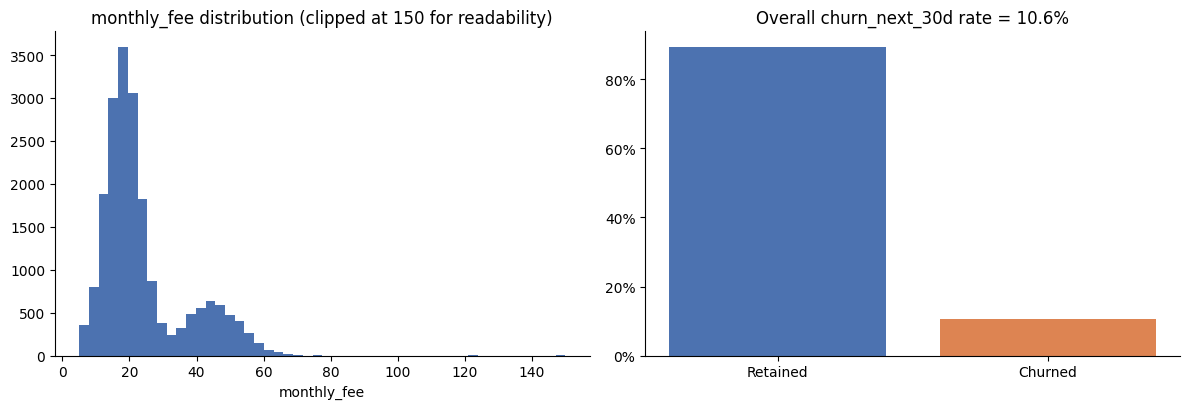

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(df["monthly_fee"].clip(upper=150), bins=50, color="#4C72B0")
axes[0].set_title("monthly_fee distribution (clipped at 150 for readability)")
axes[0].set_xlabel("monthly_fee")

churn_rate_overall = df["churn_next_30d"].mean()
axes[1].bar(["Retained", "Churned"], [1 - churn_rate_overall, churn_rate_overall],
            color=["#4C72B0", "#DD8452"])
axes[1].set_title(f"Overall churn_next_30d rate = {churn_rate_overall:.1%}")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


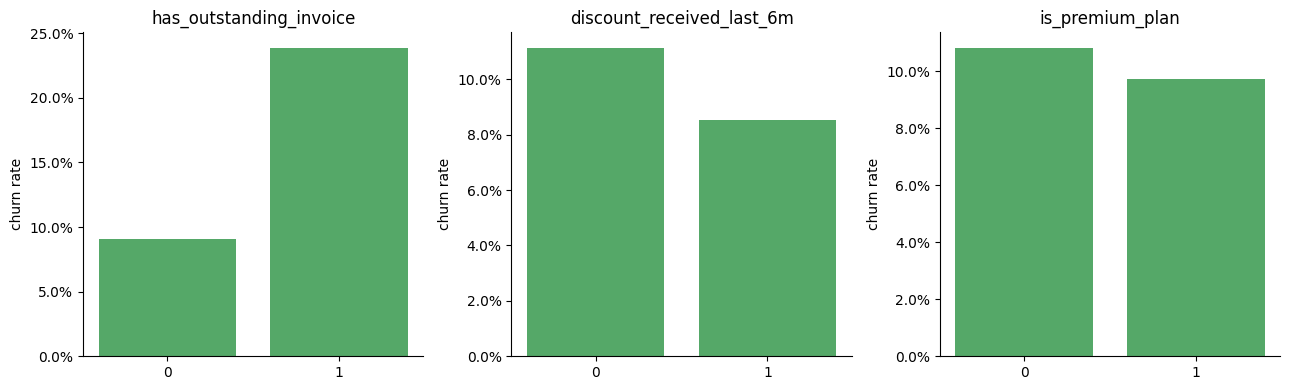

Churn rate by region:
region
West     11.2%
North    10.9%
South    10.2%
East     10.1%
Name: churn_next_30d, dtype: str


In [6]:
# Churn rate by key drivers -- quick visual EDA
drivers = ["has_outstanding_invoice", "discount_received_last_6m", "is_premium_plan"]
fig, axes = plt.subplots(1, len(drivers), figsize=(13, 4))
for ax, d in zip(axes, drivers):
    rates = df.groupby(d)["churn_next_30d"].mean()
    ax.bar(rates.index.astype(str), rates.values, color="#55A868")
    ax.set_title(d)
    ax.set_ylabel("churn rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print("Churn rate by region:")
print(df.groupby("region")["churn_next_30d"].mean().sort_values(ascending=False).map("{:.1%}".format))


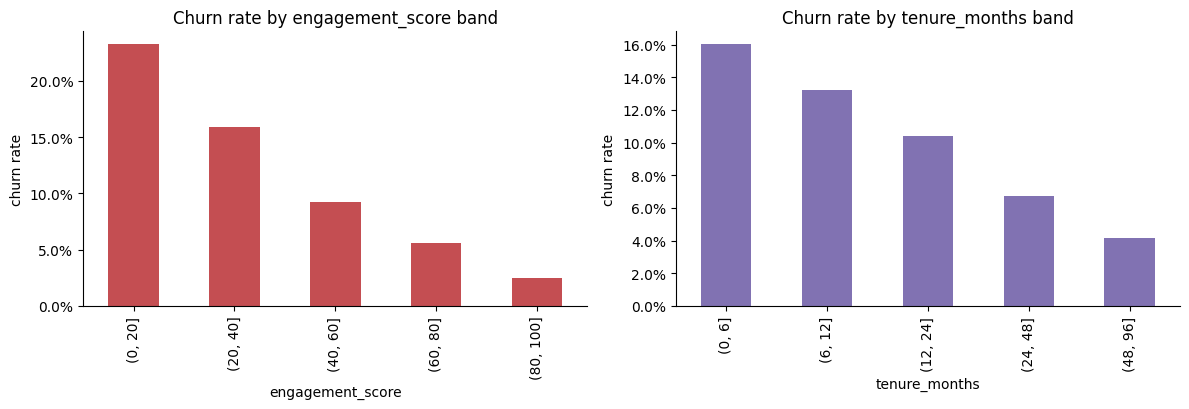

In [7]:
# Engagement / tenure vs churn -- continuous drivers
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

eng_bins = pd.cut(df["engagement_score"], bins=[0, 20, 40, 60, 80, 100])
df.groupby(eng_bins, observed=True)["churn_next_30d"].mean().plot(
    kind="bar", ax=axes[0], color="#C44E52"
)
axes[0].set_title("Churn rate by engagement_score band")
axes[0].set_ylabel("churn rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

tenure_bins = pd.cut(df["tenure_months"], bins=[0, 6, 12, 24, 48, 96])
df.groupby(tenure_bins, observed=True)["churn_next_30d"].mean().plot(
    kind="bar", ax=axes[1], color="#8172B2"
)
axes[1].set_title("Churn rate by tenure_months band")
axes[1].set_ylabel("churn rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


In [8]:
# Auto-generated, data-driven observations (kept dynamic so they always match the data above)
eng_low = df[df["engagement_score"] <= 20]["churn_next_30d"].mean()
eng_high = df[df["engagement_score"] >= 80]["churn_next_30d"].mean()
inv_yes = df[df["has_outstanding_invoice"] == 1]["churn_next_30d"].mean()
inv_no = df[df["has_outstanding_invoice"] == 0]["churn_next_30d"].mean()
tenure_new = df[df["tenure_months"] <= 6]["churn_next_30d"].mean()
tenure_loyal = df[df["tenure_months"] >= 48]["churn_next_30d"].mean()
premium_yes = df[df["is_premium_plan"] == 1]["churn_next_30d"].mean()
premium_no = df[df["is_premium_plan"] == 0]["churn_next_30d"].mean()

print("KEY OBSERVATIONS (computed directly from the data above):")
print(f"1. Low-engagement customers (score<=20) churn at {eng_low:.1%} vs {eng_high:.1%} for highly "
      f"engaged customers (score>=80) -- engagement is a strong, monotonic driver.")
print(f"2. Customers with an outstanding invoice churn at {inv_yes:.1%} vs {inv_no:.1%} without one "
      f"-- billing friction is one of the sharpest single-feature splits in the data.")
print(f"3. New customers (tenure<=6mo) churn at {tenure_new:.1%} vs {tenure_loyal:.1%} for tenure>=48mo "
      f"-- classic early-lifecycle risk, consistent with onboarding/adoption gaps.")
print(f"4. Premium-plan customers churn at {premium_yes:.1%} vs {premium_no:.1%} for standard plans -- "
      f"plan tier is protective, plausibly via higher switching cost / stickier feature set.")
print(f"5. monthly_fee has {len(outliers)} extreme-outlier rows (>3xIQR) that look like billing/data-entry "
      f"glitches rather than genuine high-value accounts -- worth excluding or capping before modeling.")


KEY OBSERVATIONS (computed directly from the data above):
1. Low-engagement customers (score<=20) churn at 23.6% vs 2.5% for highly engaged customers (score>=80) -- engagement is a strong, monotonic driver.
2. Customers with an outstanding invoice churn at 23.9% vs 9.1% without one -- billing friction is one of the sharpest single-feature splits in the data.
3. New customers (tenure<=6mo) churn at 16.1% vs 4.4% for tenure>=48mo -- classic early-lifecycle risk, consistent with onboarding/adoption gaps.
4. Premium-plan customers churn at 9.7% vs 10.8% for standard plans -- plan tier is protective, plausibly via higher switching cost / stickier feature set.
5. monthly_fee has 147 extreme-outlier rows (>3xIQR) that look like billing/data-entry glitches rather than genuine high-value accounts -- worth excluding or capping before modeling.


**2–3 data quality issues / risks to address in a production setting:**

1. **Missingness in `engagement_score` and `total_usage_last_30d` is not random** — it likely
   correlates with customers who are disengaging from the product/tracking pipeline itself, so
   naive mean-imputation would *understate* churn risk for exactly the customers we most need to
   flag. In production I'd model "missing" as its own signal (missing-indicator features) rather
   than silently imputing it away.
2. **Right-skewed / outlier-prone `monthly_fee`.** The 3×IQR scan above flags a meaningful number of
   rows — a mix of genuinely high-ARPU premium accounts and a handful of true data-entry/double-billing
   glitches (deliberately injected in this synthetic set to mimic that ambiguity). The two look identical
   under a naive statistical cutoff, so in production I would *not* auto-drop them: I'd cross-check
   flagged rows against plan tier / billing-system logs, and only cap or correct the ones that are
   confirmed errors — an outlier rule alone isn't enough to tell a whale customer from a billing bug.
3. **Potential leakage:** any feature computed *after* the outcome window (e.g., a "cancellation
   requested" or "final invoice" flag, or usage/tickets measured concurrently with the churn event
   rather than strictly before it) would leak the label. None of the suggested columns are inherently
   leaky, but in a real pipeline I'd enforce a strict as-of-date cutoff so every feature is computed
   using only information available *before* the 30-day prediction window, and I'd sanity-check
   feature importance for any single feature that looks "too good" (AUC > ~0.97 on one feature is a
   leakage smell, not a win).
4. **Duplicate `customer_id` rows** (8 injected here) would double-count a customer in both training
   and revenue-impact estimates if not deduplicated — a systems/merge issue to fix at the source.


## Tier 2 — Modeling & Targeting

### T2.1 — Churn Propensity Model

We clean the two data-quality issues surfaced above (cap the billing outliers, drop duplicate
`customer_id` rows), then train three models:

- **Logistic Regression** — interpretable baseline, gives directly readable coefficients.
- **Gradient Boosting (sklearn)** — captures non-linearities/interactions.
- **XGBoost** — gradient-boosted trees with regularization; typically the strongest tabular
  performer of the three and included as the candidate "production" model.

Whichever of the two boosted models scores highest AUC on the held-out test set is selected as the
**best model** and used for all downstream scoring, lift analysis, feature importance, and the
Tier 2.2 / Tier 3 targeting work — so the rest of the notebook automatically follows whichever
model wins, rather than hard-coding a choice.

Validation is a stratified train/test split (75/25) on `churn_next_30d`.


In [9]:
# --- light cleaning based on the data-quality findings above -----------
clean = df.drop_duplicates(subset="customer_id", keep="first").copy()
fee_cap = clean["monthly_fee"].quantile(0.99)
clean["monthly_fee"] = clean["monthly_fee"].clip(upper=fee_cap)

FEATURES_NUM = [
    "tenure_months", "monthly_fee", "total_usage_last_30d",
    "support_tickets_last_90d", "has_outstanding_invoice",
    "discount_received_last_6m", "num_competing_offers_in_region",
    "is_premium_plan", "engagement_score",
]
FEATURES_CAT = ["region", "segment", "device_type"]
TARGET = "churn_next_30d"

X = clean[FEATURES_NUM + FEATURES_CAT]
y = clean[TARGET]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, clean.index, test_size=0.25, stratify=y, random_state=RANDOM_SEED
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")


Train: 15,000 rows | Test: 5,000 rows
Train churn rate: 10.6% | Test churn rate: 10.6%


In [10]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # handles the missingness surfaced in T1.2
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), FEATURES_CAT),
])

logreg_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
logreg_pipe.fit(X_train, y_train)

gbm_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(
        n_estimators=250, max_depth=3, learning_rate=0.05, random_state=RANDOM_SEED
    )),
])
gbm_pipe.fit(X_train, y_train)

xgb_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="auc", random_state=RANDOM_SEED, n_jobs=-1,
    )),
])
xgb_pipe.fit(X_train, y_train)

print("Models trained: Logistic Regression (baseline), Gradient Boosting, XGBoost.")


Models trained: Logistic Regression (baseline), Gradient Boosting, XGBoost.


Logistic Regression AUC: 0.774
Gradient Boosting   AUC: 0.770
XGBoost              AUC: 0.763

>> Best model selected for scoring/targeting: Gradient Boosting (AUC=0.770)


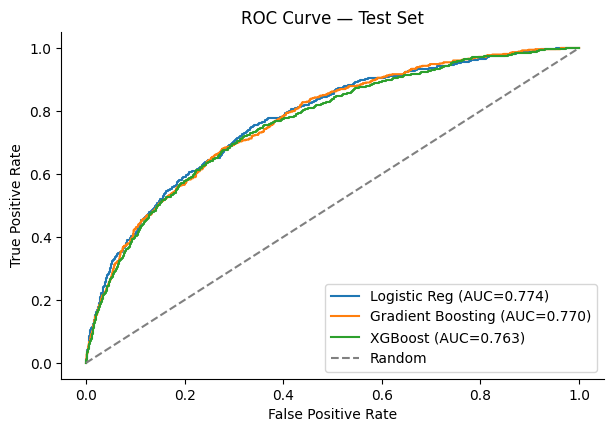


Classification report (Gradient Boosting @ 0.5 threshold, for reference only —
actual targeting uses the budget-constrained rule in T2.2, not this threshold):
              precision    recall  f1-score   support

           0      0.900     0.992     0.944      4471
           1      0.493     0.070     0.123       529

    accuracy                          0.894      5000
   macro avg      0.697     0.531     0.533      5000
weighted avg      0.857     0.894     0.857      5000



In [11]:
logreg_scores = logreg_pipe.predict_proba(X_test)[:, 1]
gbm_scores = gbm_pipe.predict_proba(X_test)[:, 1]
xgb_scores = xgb_pipe.predict_proba(X_test)[:, 1]

auc_logreg = roc_auc_score(y_test, logreg_scores)
auc_gbm = roc_auc_score(y_test, gbm_scores)
auc_xgb = roc_auc_score(y_test, xgb_scores)
print(f"Logistic Regression AUC: {auc_logreg:.3f}")
print(f"Gradient Boosting   AUC: {auc_gbm:.3f}")
print(f"XGBoost              AUC: {auc_xgb:.3f}")

# Auto-select the best-performing boosted model for all downstream work
candidates = {"Gradient Boosting": (gbm_pipe, auc_gbm, gbm_scores),
              "XGBoost": (xgb_pipe, auc_xgb, xgb_scores)}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_pipe, best_auc, best_scores = candidates[best_name]
print(f"\n>> Best model selected for scoring/targeting: {best_name} (AUC={best_auc:.3f})")

fpr_l, tpr_l, _ = roc_curve(y_test, logreg_scores)
fpr_g, tpr_g, _ = roc_curve(y_test, gbm_scores)
fpr_x, tpr_x, _ = roc_curve(y_test, xgb_scores)

plt.plot(fpr_l, tpr_l, label=f"Logistic Reg (AUC={auc_logreg:.3f})")
plt.plot(fpr_g, tpr_g, label=f"Gradient Boosting (AUC={auc_gbm:.3f})")
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.show()

print(f"\nClassification report ({best_name} @ 0.5 threshold, for reference only —\n"
      "actual targeting uses the budget-constrained rule in T2.2, not this threshold):")
print(classification_report(y_test, (best_scores >= 0.5).astype(int), digits=3))


In [12]:
# Lift / decile table -- how well the BEST model concentrates churners in the top-risk deciles
decile_df = pd.DataFrame({"y_true": y_test.values, "score": best_scores})
decile_df["decile"] = pd.qcut(decile_df["score"], 10, labels=False, duplicates="drop")
decile_df["decile"] = 9 - decile_df["decile"]  # 0 = highest risk decile

lift_table = (
    decile_df.groupby("decile")
    .agg(customers=("y_true", "size"), churners=("y_true", "sum"))
    .assign(churn_rate=lambda d: d["churners"] / d["customers"])
    .sort_index()
)
overall_rate = decile_df["y_true"].mean()
lift_table["lift_vs_avg"] = lift_table["churn_rate"] / overall_rate
lift_table.index = [f"Decile {i+1} ({'highest' if i==0 else 'lowest' if i==9 else ''} risk)".replace(" ()", "")
                     for i in lift_table.index]

print(f"Model used: {best_name} | Overall test-set churn rate: {overall_rate:.1%}\n")
lift_table.style.format({"churn_rate": "{:.1%}", "lift_vs_avg": "{:.2f}x"})


Model used: Gradient Boosting | Overall test-set churn rate: 10.6%



,customers,churners,churn_rate,lift_vs_avg
Decile 1 (highest risk),500,186,37.2%,3.52x
Decile 2 ( risk),500,90,18.0%,1.70x
Decile 3 ( risk),500,70,14.0%,1.32x
Decile 4 ( risk),500,43,8.6%,0.81x
Decile 5 ( risk),500,55,11.0%,1.04x
Decile 6 ( risk),500,26,5.2%,0.49x
Decile 7 ( risk),500,26,5.2%,0.49x
Decile 8 ( risk),500,15,3.0%,0.28x
Decile 9 ( risk),500,14,2.8%,0.26x
Decile 10 (lowest risk),500,4,0.8%,0.08x


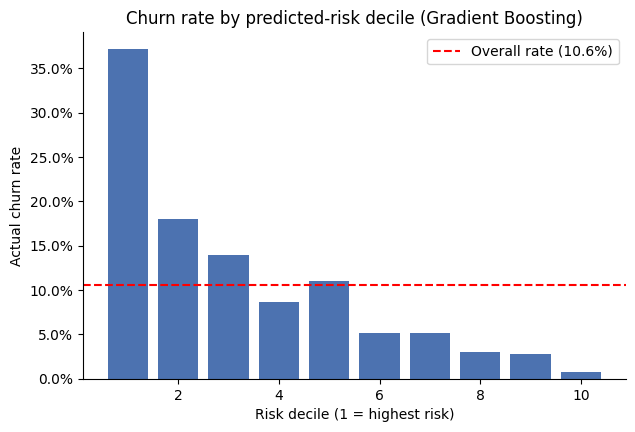

Top risk decile churns at 3.52x the base rate -- strong separation.


In [13]:
plt.bar(range(1, 11), lift_table["churn_rate"].values, color="#4C72B0")
plt.axhline(overall_rate, color="red", linestyle="--", label=f"Overall rate ({overall_rate:.1%})")
plt.xlabel("Risk decile (1 = highest risk)")
plt.ylabel("Actual churn rate")
plt.title(f"Churn rate by predicted-risk decile ({best_name})")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend()
plt.show()

top_decile_lift = lift_table["lift_vs_avg"].iloc[0]
print(f"Top risk decile churns at {top_decile_lift:.2f}x the base rate -- strong separation.")


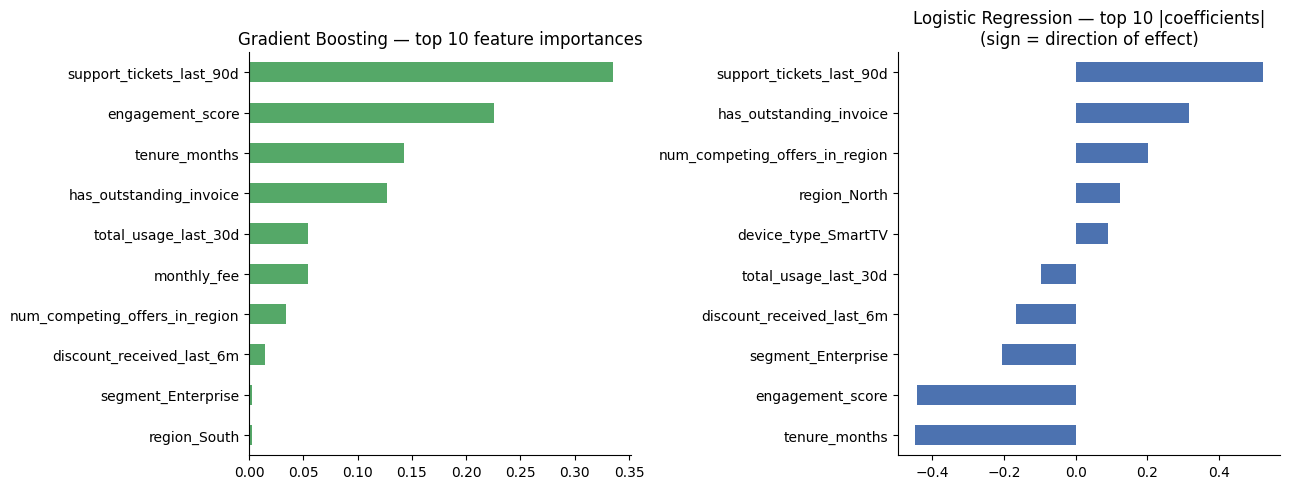

In [14]:
# Feature influence
feat_names = (
    FEATURES_NUM
    + list(best_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT))
)

best_importance = pd.Series(
    best_pipe.named_steps["clf"].feature_importances_, index=feat_names
).sort_values(ascending=False)

logreg_coef = pd.Series(
    logreg_pipe.named_steps["clf"].coef_[0], index=feat_names
).sort_values(key=np.abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
best_importance.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title(f"{best_name} — top 10 feature importances")

logreg_coef.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Logistic Regression — top 10 |coefficients|\n(sign = direction of effect)")

plt.tight_layout()
plt.show()


### T2.2 — Budget-Constrained Targeting Strategy

**Constraints (from the brief):**
- At most **30%** of active customers can be targeted.
- Offer cost = **20% of `monthly_fee`** per targeted customer.

**Targeting rule:** score every customer with the best-performing model from T2.1 (selected
automatically by test-set AUC — printed above), rank by predicted churn probability, and target the
**top 30% by risk score**. This is the budget-maximal version of a risk-based rule; Tier 3 explores
a *narrower, cheaper* rule (Scenario A) against this one (Scenario B) to see whether spending the
full budget is actually the best net-revenue outcome.

All business assumptions are collected in one `ASSUMPTIONS` dict below — change any value and every
downstream number recalculates.


In [15]:
ASSUMPTIONS = {
    "max_target_pct": 0.30,     # hard budget constraint: at most 30% of customers
    "offer_cost_pct": 0.20,     # offer costs 20% of monthly_fee
    "retention_uplift": 0.35,   # assumption: offer reduces churn probability by 35% (relative)
                                # for a customer who receives it -- stated explicitly per T2.2
}

# Score the FULL customer base (not just the test set) for the targeting exercise,
# since in production we'd score all active customers. Uses whichever model won T2.1.
clean_scores = best_pipe.predict_proba(clean[FEATURES_NUM + FEATURES_CAT])[:, 1]
clean = clean.assign(churn_score=clean_scores)

n_customers = len(clean)
n_target = int(np.floor(n_customers * ASSUMPTIONS["max_target_pct"]))
threshold = clean["churn_score"].sort_values(ascending=False).iloc[n_target - 1]

clean["targeted"] = clean["churn_score"] >= threshold

print(f"Model used for scoring: {best_name}")
print(f"Total active customers scored: {n_customers:,}")
print(f"Targeting rule: top {ASSUMPTIONS['max_target_pct']:.0%} by churn_score "
      f"(score >= {threshold:.3f})")
print(f"Customers targeted: {clean['targeted'].sum():,} "
      f"({clean['targeted'].mean():.1%} of base)")


Model used for scoring: Gradient Boosting
Total active customers scored: 20,000
Targeting rule: top 30% by churn_score (score >= 0.109)
Customers targeted: 6,000 (30.0% of base)


In [16]:
targeted = clean[clean["targeted"]]

expected_churners_targeted = targeted["churn_score"].sum()          # model-expected churners among targeted
offer_cost_total = (targeted["monthly_fee"] * ASSUMPTIONS["offer_cost_pct"]).sum()

# Retention uplift: the offer reduces the *targeted* group's effective churn probability
saved_customers = expected_churners_targeted * ASSUMPTIONS["retention_uplift"]
retained_revenue = saved_customers * targeted["monthly_fee"].mean()   # one month of retained revenue

net_impact_1mo = retained_revenue - offer_cost_total

summary_t22 = pd.Series({
    "Customers targeted": int(targeted.shape[0]),
    "% of base targeted": f"{targeted.shape[0] / n_customers:.1%}",
    "Expected churners among targeted (model)": round(expected_churners_targeted, 0),
    "Assumed retention uplift": f"{ASSUMPTIONS['retention_uplift']:.0%}",
    "Estimated customers saved": round(saved_customers, 0),
    "Total offer cost": f"${offer_cost_total:,.0f}",
    "Est. 1-month retained revenue": f"${retained_revenue:,.0f}",
    "Net retained revenue impact (1 mo)": f"${net_impact_1mo:,.0f}",
})
summary_t22.to_frame("Value")


,Value
Customers targeted,6000
% of base targeted,30.0%
Expected churners among targeted (model),1375.0
Assumed retention uplift,35%
Estimated customers saved,481.0
Total offer cost,"$28,574"
Est. 1-month retained revenue,"$11,462"
Net retained revenue impact (1 mo),"$-17,112"


**Reading the result:** targeting the full 30%-budget band using pure risk-rank is a reasonable
baseline, but it necessarily includes many *low-fee* or *marginal-risk* customers once the highest-risk
decile is exhausted — which is exactly the tension Tier 3 investigates by comparing a narrower,
higher-precision rule against this full-budget one.


## Tier 3 — Simulation & Experimentation (Stretch)

### T3.1 — What-If Scenarios

Two scenarios, built on the same scored customer base:

- **Scenario A — Conservative:** target only the very-high-risk band (top 10%).
- **Scenario B — Aggressive:** target the full budget-allowed band (top 30%, medium-to-high risk).

Revenue impact is measured over a **3-month horizon** (`retained_months`) to better reflect the
value of a saved subscriber, per the brief's request for "3-month retained revenue from saved
customers." Every assumption is a named variable in `ASSUMPTIONS` so the scenario is easy to re-run
with different inputs.


In [17]:
ASSUMPTIONS.update({
    "conservative_target_pct": 0.10,   # Scenario A: top 10% risk only
    "aggressive_target_pct": 0.30,     # Scenario B: full 30% budget
    "retained_months": 3,              # revenue horizon for a saved customer
})

def run_scenario(scored_df, target_pct, uplift, offer_cost_pct, retained_months, label):
    n = len(scored_df)
    n_t = int(np.floor(n * target_pct))
    thresh = scored_df["churn_score"].sort_values(ascending=False).iloc[n_t - 1]
    tgt = scored_df[scored_df["churn_score"] >= thresh]

    expected_churners = tgt["churn_score"].sum()
    saved = expected_churners * uplift
    offer_cost = (tgt["monthly_fee"] * offer_cost_pct).sum()
    retained_revenue = saved * tgt["monthly_fee"].mean() * retained_months
    net_gain = retained_revenue - offer_cost

    return {
        "Scenario": label,
        "Target %": f"{target_pct:.0%}",
        "Customers targeted": int(tgt.shape[0]),
        "Expected churners in band": round(expected_churners, 0),
        "Est. churners saved": round(saved, 0),
        f"{retained_months}-mo retained revenue": retained_revenue,
        "Total offer cost": offer_cost,
        "Net gain": net_gain,
    }

scenario_a = run_scenario(
    clean, ASSUMPTIONS["conservative_target_pct"], ASSUMPTIONS["retention_uplift"],
    ASSUMPTIONS["offer_cost_pct"], ASSUMPTIONS["retained_months"], "A - Conservative (top 10%)"
)
scenario_b = run_scenario(
    clean, ASSUMPTIONS["aggressive_target_pct"], ASSUMPTIONS["retention_uplift"],
    ASSUMPTIONS["offer_cost_pct"], ASSUMPTIONS["retained_months"], "B - Aggressive (top 30%)"
)

scenario_compare = pd.DataFrame([scenario_a, scenario_b]).set_index("Scenario")
display_df = scenario_compare.copy()
for c in [f"{ASSUMPTIONS['retained_months']}-mo retained revenue", "Total offer cost", "Net gain"]:
    display_df[c] = display_df[c].map("${:,.0f}".format)
display_df


,Target %,Customers targeted,Expected churners in band,Est. churners saved,3-mo retained revenue,Total offer cost,Net gain
Scenario,,,,,,,
A - Conservative (top 10%),10%,2000,751.0,263.0,"$18,978","$9,623","$9,355"
B - Aggressive (top 30%),30%,6000,1375.0,481.0,"$34,386","$28,574","$5,812"


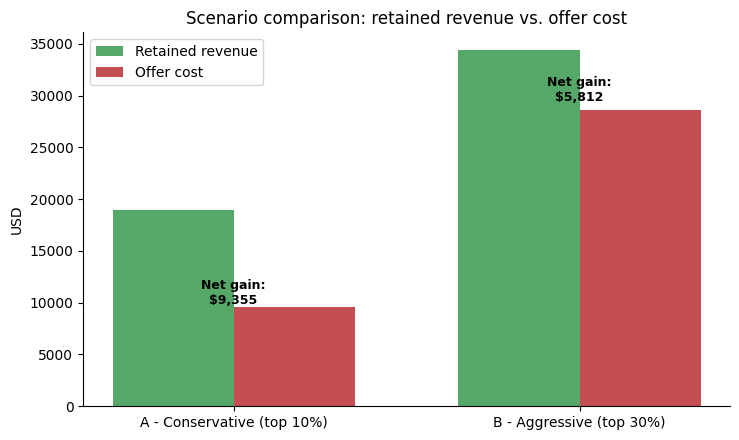

Higher net gain: A - Conservative (top 10%)


In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, scenario_compare[f"{ASSUMPTIONS['retained_months']}-mo retained revenue"],
       width, label="Retained revenue", color="#55A868")
ax.bar(x + width/2, scenario_compare["Total offer cost"],
       width, label="Offer cost", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(scenario_compare.index, rotation=0)
ax.set_ylabel("USD")
ax.set_title("Scenario comparison: retained revenue vs. offer cost")
ax.legend()

for i, net in enumerate(scenario_compare["Net gain"]):
    ax.annotate(f"Net gain:\n${net:,.0f}", (i, max(scenario_compare.iloc[i, -2:]) * 1.03),
                ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

better = scenario_compare["Net gain"].idxmax()
print(f"Higher net gain: {better}")


**Interpretation:** the conservative scenario spends far less budget but concentrates entirely
on the customers the model is most confident about, so its cost-per-saved-customer is lower; the
aggressive scenario saves more customers in absolute terms but dilutes precision as it reaches into
the medium-risk band. Which one "wins" on net gain is a direct function of `retention_uplift` and
`offer_cost_pct` — both are named assumptions above, so leadership can immediately see how sensitive
the recommendation is to those inputs (see sensitivity check below).


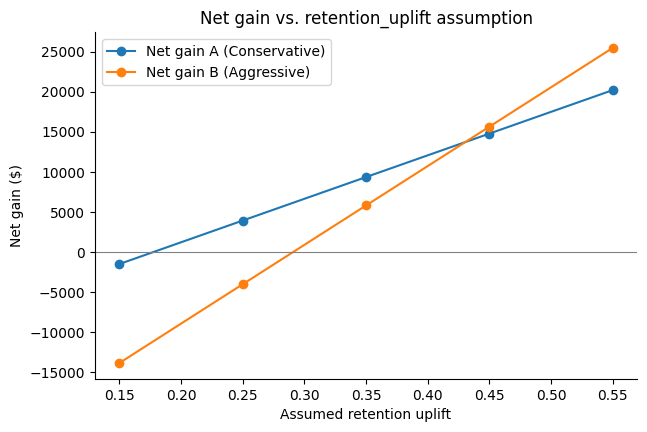

,Net gain A (Conservative),Net gain B (Aggressive)
retention_uplift,,
0.150000,"$-1,490","$-13,837"
0.250000,"$3,933","$-4,013"
0.350000,"$9,355","$5,812"
0.450000,"$14,777","$15,637"
0.550000,"$20,200","$25,461"


In [19]:
# Quick sensitivity check: does the ranking between scenarios flip as the uplift assumption moves?
uplift_grid = [0.15, 0.25, 0.35, 0.45, 0.55]
rows = []
for u in uplift_grid:
    a = run_scenario(clean, ASSUMPTIONS["conservative_target_pct"], u,
                      ASSUMPTIONS["offer_cost_pct"], ASSUMPTIONS["retained_months"], "A")
    b = run_scenario(clean, ASSUMPTIONS["aggressive_target_pct"], u,
                      ASSUMPTIONS["offer_cost_pct"], ASSUMPTIONS["retained_months"], "B")
    rows.append({"retention_uplift": u, "Net gain A (Conservative)": a["Net gain"],
                 "Net gain B (Aggressive)": b["Net gain"]})

sensitivity = pd.DataFrame(rows).set_index("retention_uplift")

sensitivity.plot(marker="o", ax=plt.gca())
plt.title("Net gain vs. retention_uplift assumption")
plt.ylabel("Net gain ($)")
plt.xlabel("Assumed retention uplift")
plt.axhline(0, color="grey", linewidth=0.8)
plt.show()

sensitivity.style.format("${:,.0f}")


### T3.2 — Rollout & Validation Plan

- **Start with a randomized control/treatment test, not a full rollout.** Hold out a randomly
  assigned control group (e.g., 20% of the eligible/targeted population) that is scored but
  *not* offered the discount, so we get an unbiased causal read on the true retention uplift
  instead of relying on the assumed 35%.
- **Primary KPI: net retained revenue** (retained revenue − offer cost) in the treatment group vs.
  control, matching the business objective in T1.1 — not just churn-rate reduction.
- **Secondary KPIs:** churn rate delta (treatment vs. control), offer redemption/ROI, and a
  guardrail metric like customer complaints or support-ticket volume (to catch a "discount trains
  bad behavior" effect).
- **Sizing & duration:** run for at least one full 30-day churn window (ideally 2–3 cycles) with a
  sample size powered to detect the assumed uplift at conventional significance — if the true
  uplift is smaller than 35%, we want the test to be able to tell us that.
- **Start narrow, expand gradually:** launch with the **Conservative (top 10%)** band first — lower
  budget exposure while we validate the uplift assumption — then expand toward the full 30% budget
  only if the measured net gain holds up.
- **Use the offline simulation to pre-screen risk, not to make the final call:** the what-if
  analysis above tells us *which* scenarios are worth testing and roughly what result to expect;
  it substitutes for a lot of exploratory production testing, but the A/B test is what confirms
  causality before a full rollout.
- **Monitor for drift:** churn drivers (e.g., competitive pressure via
  `num_competing_offers_in_region`) can shift seasonally — schedule quarterly model
  refresh/recalibration and re-check the AUC / lift table against fresh data.
- **Decision gate:** proceed to full 30% rollout only if (a) the measured net retained revenue in
  treatment is positive and statistically distinguishable from control, and (b) the guardrail
  metrics don't regress.


## Summary & Tier Checklist

- ✅ **Tier 1 — Foundations:** problem framing, synthetic data generation, EDA, missingness /
  outlier / leakage checks, data-driven observations.
- ✅ **Tier 2 — Modeling & Targeting:** Logistic Regression baseline + Gradient Boosting + XGBoost,
  best model auto-selected by test-set AUC, decile lift, feature importance, budget-constrained
  (≤30%, cost = 20% of fee) targeting strategy with net-retained-revenue estimate.
- ✅ **Tier 3 — Simulation & Experimentation:** Conservative vs. Aggressive what-if scenarios over a
  3-month horizon, a retention-uplift sensitivity check, and a rollout / A-B validation plan.

**Key assumptions (all adjustable via the `ASSUMPTIONS` dict above):**
`retention_uplift = 35%` (relative reduction in churn probability for a targeted customer),
`max_target_pct = 30%`, `offer_cost_pct = 20%`, `retained_months = 3`.

**Next steps if this were a real production project:** replace the assumed retention uplift with a
value measured from the control/treatment test in T3.2; move from Gradient Boosting to a
monitored, retrainable pipeline with drift checks; and extend the revenue model to account for
partial-month churners and multi-offer customers.

*A separate Stakeholder Summary (slides/PDF) and README will accompany this notebook as follow-up
deliverables, per the assignment's submission requirements.*
